# Per‑region Benth OU + Neural Networks (Model 1: NN calibration)

Your CSV has **many regions** (multiple rows per date). This notebook trains **one independent model per region**:

- Fit seasonal mean $s_r(t)$ (harmonic regression) for each region $r$
- Residuals $X_{r,t}=T_{r,t}-s_r(t)$
- Train a neural network that predicts $(\kappa_{r,t},\sigma_{r,t})$ from a rolling window and DOY features

Outputs per region:
- training / test NLL curves
- learned $\kappa_{r,t}$ and $\sigma_{r,t}$ over time
- standardized residual diagnostics
- optional Monte‑Carlo simulation + HDD example

**Note:** This is the "Model 1" approach (NN calibrates OU parameters).

In [14]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from dataclasses import dataclass

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Load your CSV

Expected columns:
- `date`
- `region_code`
- `temp`

If your column names differ, rename them below.

In [15]:
CSV_PATH = "../EDA/region_avg.csv"  # <- change if needed
DATE_COL = "date"
REGION_COL = "region_code"
TEMP_COL = "daily_avg_temperature"

df_raw = pd.read_csv(CSV_PATH)
df_raw = df_raw.rename(columns={DATE_COL:"date", REGION_COL:"region_code", TEMP_COL:"daily_avg_temperature"})

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["temp"] = pd.to_numeric(df_raw["daily_avg_temperature"], errors="coerce")
df_raw["region_code"] = pd.to_numeric(df_raw["region_code"], errors="coerce")

df_raw = df_raw.dropna(subset=["date","temp","region_code"]).copy()
df_raw["region_code"] = df_raw["region_code"].astype(int)

print(df_raw.head())
print(df_raw.tail())
print("shape:", df_raw.shape)
print("regions:", df_raw["region_code"].nunique())


        date  region_code  daily_avg_temperature  temp
0 1970-01-01           11                  -2.40 -2.40
1 1970-01-01           24                  -2.50 -2.50
2 1970-01-01           28                   4.40  4.40
3 1970-01-01           44                  -3.35 -3.35
4 1970-01-01           52                  -0.85 -0.85
             date  region_code  daily_avg_temperature      temp
158009 2024-12-31           28               5.875000  5.875000
158010 2024-12-31           32               4.795455  4.795455
158011 2024-12-31           44              -0.102632 -0.102632
158012 2024-12-31           52               5.662500  5.662500
158013 2024-12-31           53               8.276667  8.276667
shape: (151743, 4)
regions: 8


## 2) Helper functions

In [16]:
def design_matrix_seasonality(dates: pd.Series, K: int = 3, include_trend: bool = True) -> np.ndarray:
    n = len(dates)
    doy = dates.dt.dayofyear.values.astype(float)
    parts = [np.ones(n)]
    if include_trend:
        t = np.arange(n) / 365.0
        parts.append(t)
    for k in range(1, K+1):
        parts.append(np.sin(2*np.pi*k*doy/365.0))
        parts.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(parts)

def fit_seasonal_mean(dates: pd.Series, temp: np.ndarray, K: int = 3):
    X = design_matrix_seasonality(dates, K=K, include_trend=True)
    y = temp.astype(float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    s_hat = X @ beta
    return s_hat, beta

def doy_features(dates: pd.Series, harmonics: int = 3) -> np.ndarray:
    doy = dates.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, harmonics+1):
        feats.append(np.sin(2*np.pi*k*doy/365.0))
        feats.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(feats)

def make_windows(x: np.ndarray, doy_feat: np.ndarray, window: int = 30):
    x = np.asarray(x, dtype=np.float32)
    doy_feat = np.asarray(doy_feat, dtype=np.float32)
    N, F = doy_feat.shape
    xs, xt, y, idx = [], [], [], []
    for t in range(window, N-1):
        inp = np.concatenate([x[t-window:t], doy_feat[t]], axis=0)
        xs.append(inp)
        xt.append(x[t])
        y.append(x[t+1])
        idx.append(t)
    return np.stack(xs), np.array(xt), np.array(y), np.array(idx)

class CalibNet(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, kappa_max: float = 0.5):
        super().__init__()
        self.kappa_max = kappa_max
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),  # raw_kappa, raw_sigma
        )
        self.softplus = nn.Softplus()

    def forward(self, x):
        raw = self.net(x)
        kappa = self.kappa_max * torch.sigmoid(raw[:, 0]) + 1e-6
        sigma = self.softplus(raw[:, 1]) + 1e-6
        return kappa, sigma

def ou_nll_euler(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean = x_t - kappa * x_t * dt
    var = (sigma ** 2) * dt
    var = torch.clamp(var, min=1e-6)  # prevents log(0)/div0
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()


## 3) Per‑region training configuration

In [17]:
# Model / data hyperparameters
K_HARMONICS = 3       # seasonal mean harmonics
DOY_HARMONICS = 3     # NN time-of-year features
WINDOW = 30           # rolling residual window length
DT = 1.0              # daily step
EPOCHS = 800          # increase if you want
LR = 1e-3
HIDDEN = 64
KAPPA_MAX = 0.5       # daily kappa bound

# Regions to train (edit if you want a subset)
regions = sorted(df_raw["region_code"].unique().tolist())
print("Total regions:", len(regions))
print("Regions:", regions)


Total regions: 8
Regions: [11, 24, 27, 28, 32, 44, 52, 53]


## 4) Train one model per region

This loop will:
1. Filter data to one region
2. Fit seasonal mean $s_r(t)$
3. Compute residuals $X_{r,t}$
4. Standardize residuals (stability)
5. Train CalibNet via OU likelihood
6. Save model weights + store diagnostics


In [18]:
results = []              # summary rows
models = {}               # region -> model (in-memory)
region_artifacts = {}     # region -> dict of arrays for plots/diagnostics

OUT_DIR = "per_region_models"
os.makedirs(OUT_DIR, exist_ok=True)

for r in regions:
    dfr = df_raw[df_raw["region_code"] == r].sort_values("date").reset_index(drop=True)

    # Ensure one value per date for this region
    dfr = dfr.groupby("date", as_index=False)["temp"].mean()
    if len(dfr) < (WINDOW + 60):
        results.append({"region": r, "status":"skipped (too short)", "n_days": len(dfr)})
        continue

    # Fit seasonal mean and residuals
    s_hat, beta = fit_seasonal_mean(dfr["date"], dfr["temp"].values, K=K_HARMONICS)
    x = (dfr["temp"].values - s_hat).astype(np.float32)

    # Standardize residuals (important!)
    x_mean = float(np.mean(x))
    x_std  = float(np.std(x) + 1e-8)
    xz = (x - x_mean) / x_std

    # Build features/windows
    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    # Train/test split
    N = X_in.shape[0]
    split = int(0.8 * N)
    X_train = torch.tensor(X_in[:split], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[:split], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[:split], dtype=torch.float32, device=device)

    X_test = torch.tensor(X_in[split:], dtype=torch.float32, device=device)
    x_t_test = torch.tensor(x_t[split:], dtype=torch.float32, device=device)
    x_tp1_test = torch.tensor(x_tp1[split:], dtype=torch.float32, device=device)

    # Model
    model = CalibNet(in_dim=X_train.shape[1], hidden=HIDDEN, kappa_max=KAPPA_MAX).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    # Train
    train_curve, test_curve, epochs_logged = [], [], []
    for epoch in range(1, EPOCHS+1):
        model.train()
        kappa, sigma = model(X_train)
        loss = ou_nll_euler(x_t_train, x_tp1_train, kappa, sigma, dt=DT)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if epoch % 50 == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                k_te, s_te = model(X_test)
                loss_te = ou_nll_euler(x_t_test, x_tp1_test, k_te, s_te, dt=DT)
            train_curve.append(float(loss.item()))
            test_curve.append(float(loss_te.item()))
            epochs_logged.append(epoch)

    # Evaluate on all windows
    model.eval()
    with torch.no_grad():
        k_all, s_all = model(torch.tensor(X_in, dtype=torch.float32, device=device))
    k_all = k_all.detach().cpu().numpy()
    s_all = s_all.detach().cpu().numpy()

    # Standardized residuals on test
    with torch.no_grad():
        k_te, s_te = model(X_test)
        mean_te = x_t_test - k_te * x_t_test * DT
        z_te = (x_tp1_test - mean_te) / (s_te * np.sqrt(DT))
    z_te = z_te.detach().cpu().numpy()

    # Save model + region params needed to simulate back in original units
    save_path = os.path.join(OUT_DIR, f"calibnet_region_{r}.pt")
    torch.save({
        "state_dict": model.state_dict(),
        "window": WINDOW,
        "doy_harmonics": DOY_HARMONICS,
        "k_harmonics": K_HARMONICS,
        "beta": beta,
        "x_mean": x_mean,
        "x_std": x_std,
        "kappa_max": KAPPA_MAX,
        "hidden": HIDDEN,
    }, save_path)

    models[r] = model
    region_artifacts[r] = {
        "df": dfr,
        "beta": beta,
        "s_hat": s_hat,
        "x": x,            # original residual
        "xz": xz,          # standardized residual
        "idx_t": idx_t,
        "kappa_all": k_all,
        "sigma_all": s_all,
        "train_curve": train_curve,
        "test_curve": test_curve,
        "epochs_logged": epochs_logged,
        "z_test": z_te,
        "save_path": save_path,
    }

    results.append({
        "region": r,
        "status":"ok",
        "n_days": len(dfr),
        "train_nll_last": train_curve[-1] if len(train_curve) else np.nan,
        "test_nll_last": test_curve[-1] if len(test_curve) else np.nan,
        "z_mean": float(np.mean(z_te)),
        "z_std": float(np.std(z_te)),
        "model_path": save_path,
    })

summary = pd.DataFrame(results).sort_values(["status","region"])
summary.head(), summary.tail(), summary.shape


(   region status  n_days  train_nll_last  test_nll_last    z_mean     z_std  \
 0      11     ok   20089       -0.198148       0.635269  0.036696  1.631856   
 1      24     ok   20089       -0.201722       0.603723  0.019154  1.622982   
 2      27     ok   15170       -0.197129       0.906216  0.026705  1.762808   
 3      28     ok   20089       -0.180931       0.505119  0.041732  1.533553   
 4      32     ok   16039       -0.210775       0.697648  0.047710  1.692898   
 
                                 model_path  
 0  per_region_models/calibnet_region_11.pt  
 1  per_region_models/calibnet_region_24.pt  
 2  per_region_models/calibnet_region_27.pt  
 3  per_region_models/calibnet_region_28.pt  
 4  per_region_models/calibnet_region_32.pt  ,
    region status  n_days  train_nll_last  test_nll_last    z_mean     z_std  \
 3      28     ok   20089       -0.180931       0.505119  0.041732  1.533553   
 4      32     ok   16039       -0.210775       0.697648  0.047710  1.692898   
 

### Summary table

In [19]:
summary

,region,status,n_days,train_nll_last,test_nll_last,z_mean,z_std,model_path
0,11,ok,20089,-0.198148,0.635269,0.036696,1.631856,per_region_models/calibnet_region_11.pt
1,24,ok,20089,-0.201722,0.603723,0.019154,1.622982,per_region_models/calibnet_region_24.pt
2,27,ok,15170,-0.197129,0.906216,0.026705,1.762808,per_region_models/calibnet_region_27.pt
3,28,ok,20089,-0.180931,0.505119,0.041732,1.533553,per_region_models/calibnet_region_28.pt
4,32,ok,16039,-0.210775,0.697648,0.047710,1.692898,per_region_models/calibnet_region_32.pt
5,44,ok,20089,-0.248074,0.360381,0.030358,1.470661,per_region_models/calibnet_region_44.pt
6,52,ok,20089,-0.145878,0.328326,0.038181,1.388054,per_region_models/calibnet_region_52.pt
7,53,ok,20089,-0.191396,0.428913,0.006855,1.498278,per_region_models/calibnet_region_53.pt


The neural-network calibrated Ornstein–Uhlenbeck (OU) temperature model was successfully trained for all eight regions, as indicated by the status = ok across the table. Most regions have approximately 20,000 daily observations (about 55 years of data), while regions 27 and 32 have shorter series (~15–16k days), which may affect model stability and predictive performance.

The training negative log-likelihood (train_nll_last) values are relatively similar across regions (around −0.15 to −0.25), indicating that the model fits the training data consistently well. However, the test negative log-likelihood (test_nll_last) values are higher, which is expected since the test set contains unseen data. Region 27 shows the largest test NLL (≈0.91), suggesting that the model generalizes less well there, possibly due to the shorter dataset or higher variability in that region’s temperature dynamics.

The standardized residual means (z_mean) are all very close to zero (between 0.006 and 0.048), indicating that the model does not exhibit systematic bias in predicting temperature anomalies. This suggests that the mean-reversion component of the OU process is well specified.

However, the standard deviation of the standardized residuals (z_std) ranges from 1.39 to 1.76, which is noticeably larger than the ideal value of 1 expected under a correctly specified Gaussian OU model. This indicates that the model underestimates the true volatility of temperature shocks, meaning that extreme temperature changes occur more frequently in the data than predicted by the model. Regions 44 and 52 show the closest values to 1 (best volatility fit), while region 27 exhibits the largest deviation, again suggesting greater variability or weaker model fit for that region.

Overall, the results show that the neural-network OU framework captures the mean dynamics of temperature anomalies well, but tends to underestimate volatility across regions, particularly in areas with shorter data records or more variable climates.

## 5) Plot diagnostics for a chosen region

In [20]:
# Pick a region to inspect
REGION_TO_PLOT = summary[summary["status"]=="ok"]["region"].iloc[0]
REGION_TO_PLOT


np.int64(11)

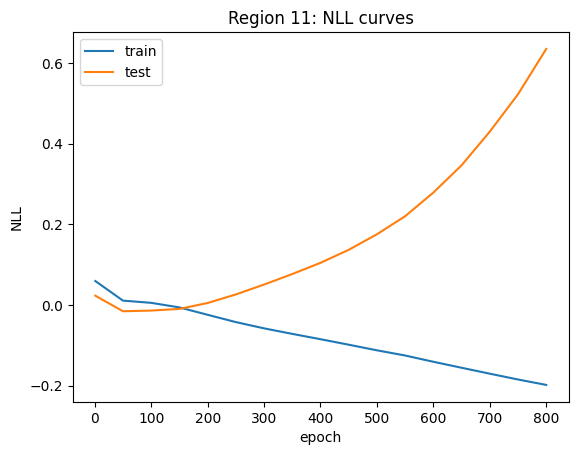

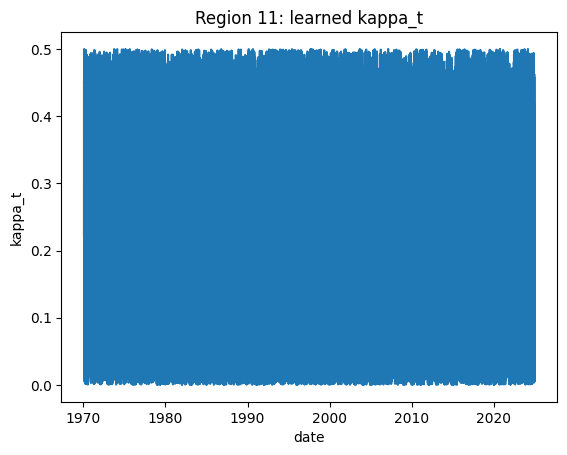

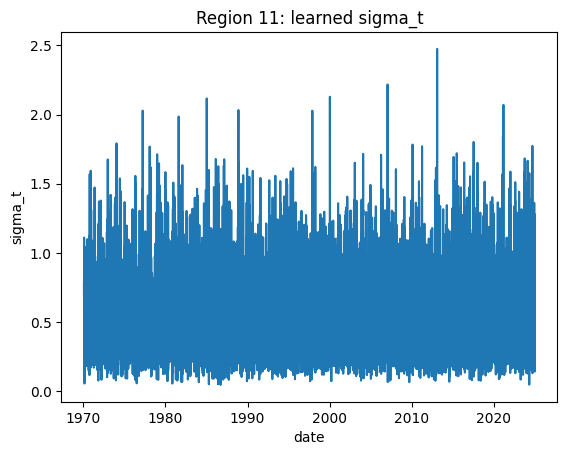

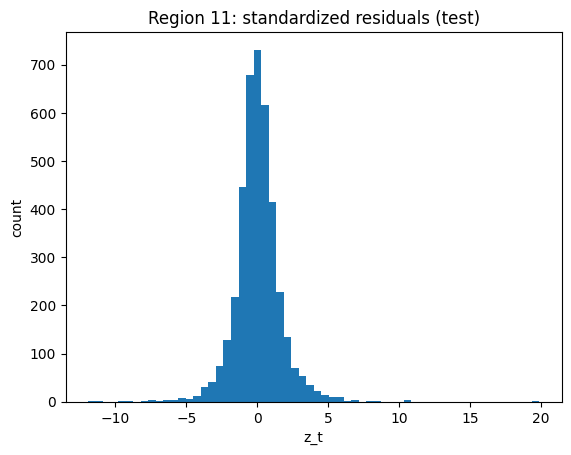

z mean: 0.036696165800094604 z std: 1.6318564414978027
saved model: per_region_models/calibnet_region_11.pt


In [21]:
art = region_artifacts[REGION_TO_PLOT]
dfr = art["df"]

dates_k = dfr.loc[art["idx_t"], "date"].values

plt.figure()
plt.plot(art["epochs_logged"], art["train_curve"], label="train")
plt.plot(art["epochs_logged"], art["test_curve"], label="test")
plt.title(f"Region {REGION_TO_PLOT}: NLL curves")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

plt.figure()
plt.plot(dates_k, art["kappa_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned kappa_t")
plt.xlabel("date")
plt.ylabel("kappa_t")
plt.show()

plt.figure()
plt.plot(dates_k, art["sigma_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned sigma_t")
plt.xlabel("date")
plt.ylabel("sigma_t")
plt.show()

plt.figure()
plt.hist(art["z_test"], bins=60)
plt.title(f"Region {REGION_TO_PLOT}: standardized residuals (test)")
plt.xlabel("z_t")
plt.ylabel("count")
plt.show()

print("z mean:", float(np.mean(art["z_test"])), "z std:", float(np.std(art["z_test"])))
print("saved model:", art["save_path"])


## 6) Optional: simulate temperatures for that region and compute HDD example

This uses the trained NN to produce $(\kappa_t,\sigma_t)$ step-by-step. Residuals are simulated in **standardized units** and then mapped back to original units.

In [22]:
@dataclass
class SimConfig:
    horizon_days: int = 90
    n_paths: int = 2000
    base_temp: float = 18.0
    tick_value: float = 1.0
    dt: float = 1.0

def simulate_region(art, model, start_index: int, sim: SimConfig):
    dfr = art["df"].copy()
    beta = art["beta"]
    x_mean, x_std = float(np.mean(art["x"])), float(np.std(art["x"]) + 1e-8)

    # Start from observed day
    x0 = float(art["x"][start_index])
    x0z = (x0 - x_mean) / x_std

    start_date = dfr.loc[start_index, "date"]
    dates = pd.date_range(start_date, periods=sim.horizon_days+1, freq="D")

    # seasonal mean future
    X_design = design_matrix_seasonality(pd.Series(dates), K=K_HARMONICS, include_trend=True)
    s_future = X_design @ beta

    # history window from standardized residuals
    xz_series = ((art["x"] - x_mean) / x_std).astype(np.float32)
    hist = xz_series[max(0, start_index-WINDOW):start_index]
    if len(hist) < WINDOW:
        hist = np.pad(hist, (WINDOW-len(hist), 0), mode="edge")

    X_paths_z = np.zeros((sim.n_paths, sim.horizon_days+1), dtype=np.float32)
    T_paths = np.zeros((sim.n_paths, sim.horizon_days+1), dtype=np.float32)

    X_paths_z[:, 0] = x0z
    T_paths[:, 0] = s_future[0] + x0

    for t in range(sim.horizon_days):
        feat = doy_features(pd.Series([dates[t]]), harmonics=DOY_HARMONICS).astype(np.float32).reshape(-1)
        inp = np.concatenate([hist[-WINDOW:], feat], axis=0)[None, :]
        inp_t = torch.tensor(inp, dtype=torch.float32, device=device)

        with torch.no_grad():
            kappa_t, sigma_t = model(inp_t)
        kappa_t = float(kappa_t.item())
        sigma_t = float(sigma_t.item())

        eps = np.random.randn(sim.n_paths).astype(np.float32)
        x_next_z = X_paths_z[:, t] - kappa_t * X_paths_z[:, t] * sim.dt + sigma_t * np.sqrt(sim.dt) * eps

        X_paths_z[:, t+1] = x_next_z

        # map back to original residual + temp
        x_next = x_next_z * x_std + x_mean
        T_paths[:, t+1] = s_future[t+1] + x_next

        hist = np.append(hist, x_next_z.mean())

    return T_paths

SIM_REGION = REGION_TO_PLOT
sim_cfg = SimConfig(horizon_days=90, n_paths=3000, base_temp=18.0, tick_value=1.0)

art = region_artifacts[SIM_REGION]
model = models[SIM_REGION]
# start from last 20% of sample
start_index = int(len(art["df"]) * 0.85)

T_paths = simulate_region(art, model, start_index=start_index, sim=sim_cfg)
T_paths.shape


(3000, 91)

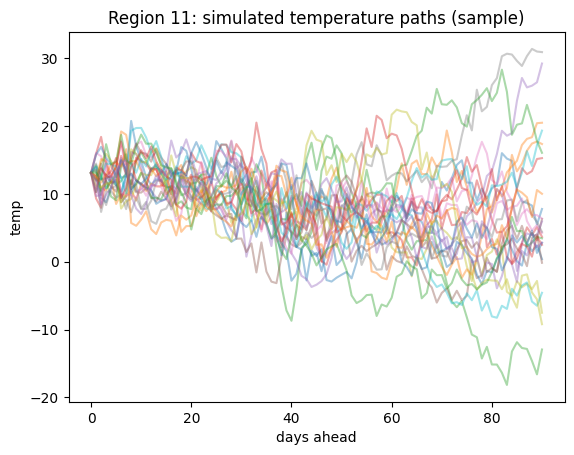

Expected HDD: 985.0858154296875
Std HDD: 225.34780883789062
Expected payoff: 985.0858154296875


In [23]:
plt.figure()
for i in range(25):
    plt.plot(T_paths[i], alpha=0.4)
plt.title(f"Region {SIM_REGION}: simulated temperature paths (sample)")
plt.xlabel("days ahead")
plt.ylabel("temp")
plt.show()

K_base = sim_cfg.base_temp
hdd = np.maximum(0.0, K_base - T_paths[:, 1:]).sum(axis=1)
payoff = sim_cfg.tick_value * hdd
print("Expected HDD:", float(hdd.mean()))
print("Std HDD:", float(hdd.std()))
print("Expected payoff:", float(payoff.mean()))


# MODEL 1B: Per-region OU + NN with explicit seasonal volatility head
#
#### This section keeps the original per-region OU+NN results unchanged,
#### and trains a second model where:
##
####   kappa_t = f_kappa(residual history)
####   sigma_t = f_sigma(residual history, seasonal DOY features)
##
#### The goal is to improve volatility calibration, especially z_std.

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

class CalibNetSeasonalSigma(nn.Module):
    def __init__(self, window: int, doy_dim: int, hidden: int = 64, kappa_max: float = 0.5):
        super().__init__()
        self.window = window
        self.doy_dim = doy_dim
        self.kappa_max = kappa_max
        self.softplus = nn.Softplus()

        # kappa branch: mainly driven by residual history
        self.kappa_net = nn.Sequential(
            nn.Linear(window, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

        # sigma branch: residual history + seasonal features
        self.sigma_net = nn.Sequential(
            nn.Linear(window + doy_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        """
        x shape: (batch, window + doy_dim)
        first 'window' columns: residual history
        last 'doy_dim' columns: seasonal features
        """
        x_hist = x[:, :self.window]
        x_doy = x[:, self.window:]

        raw_kappa = self.kappa_net(x_hist).squeeze(-1)
        raw_sigma = self.sigma_net(torch.cat([x_hist, x_doy], dim=1)).squeeze(-1)

        kappa = self.kappa_max * torch.sigmoid(raw_kappa) + 1e-6
        sigma = self.softplus(raw_sigma) + 1e-6
        return kappa, sigma


def ou_nll_euler_safe(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean = x_t - kappa * x_t * dt
    var = (sigma ** 2) * dt
    var = torch.clamp(var, min=1e-6)
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()

In [25]:
def doy_features_seasonal_sigma(dates: pd.Series, harmonics: int = 5) -> np.ndarray:
    """
    Stronger seasonal encoding for volatility.
    Returns shape (N, 2*harmonics)
    """
    doy = dates.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, harmonics + 1):
        feats.append(np.sin(2 * np.pi * k * doy / 365.0))
        feats.append(np.cos(2 * np.pi * k * doy / 365.0))
    return np.column_stack(feats)

In [26]:
# --- Hyperparameters for the seasonal-sigma remake ---
K_HARMONICS_SS = 3          # seasonal mean harmonics
DOY_HARMONICS_SS = 5        # stronger seasonal features for sigma
WINDOW_SS = 30
DT_SS = 1.0
EPOCHS_SS = 800
LR_SS = 1e-3
HIDDEN_SS = 64
KAPPA_MAX_SS = 0.5

OUT_DIR_SS = "per_region_models_seasonal_sigma"
os.makedirs(OUT_DIR_SS, exist_ok=True)

In [27]:
results_seasonal_sigma = []
models_seasonal_sigma = {}
region_artifacts_seasonal_sigma = {}

regions_ss = sorted(df_raw["region_code"].unique().tolist())

for r in regions_ss:
    dfr = df_raw[df_raw["region_code"] == r].sort_values("date").reset_index(drop=True)

    # Ensure one value per date per region
    dfr = dfr.groupby("date", as_index=False)["temp"].mean()

    if len(dfr) < (WINDOW_SS + 60):
        results_seasonal_sigma.append({
            "region": r,
            "status": "skipped (too short)",
            "n_days": len(dfr)
        })
        continue

    # 1) Fit seasonal mean
    s_hat, beta = fit_seasonal_mean(dfr["date"], dfr["temp"].values, K=K_HARMONICS_SS)

    # 2) Residuals
    x = (dfr["temp"].values - s_hat).astype(np.float32)

    # 3) Standardize residuals for stable training
    x_mean = float(np.mean(x))
    x_std = float(np.std(x) + 1e-8)
    xz = (x - x_mean) / x_std

    # 4) Features
    doy_feat_ss = doy_features_seasonal_sigma(dfr["date"], harmonics=DOY_HARMONICS_SS)

    X_in_ss, x_t_ss, x_tp1_ss, idx_t_ss = make_windows(
        xz,
        doy_feat_ss,
        window=WINDOW_SS
    )

    N = X_in_ss.shape[0]
    split = int(0.8 * N)

    X_train_ss = torch.tensor(X_in_ss[:split], dtype=torch.float32, device=device)
    x_t_train_ss = torch.tensor(x_t_ss[:split], dtype=torch.float32, device=device)
    x_tp1_train_ss = torch.tensor(x_tp1_ss[:split], dtype=torch.float32, device=device)

    X_test_ss = torch.tensor(X_in_ss[split:], dtype=torch.float32, device=device)
    x_t_test_ss = torch.tensor(x_t_ss[split:], dtype=torch.float32, device=device)
    x_tp1_test_ss = torch.tensor(x_tp1_ss[split:], dtype=torch.float32, device=device)

    # 5) Model
    model_ss = CalibNetSeasonalSigma(
        window=WINDOW_SS,
        doy_dim=2 * DOY_HARMONICS_SS,
        hidden=HIDDEN_SS,
        kappa_max=KAPPA_MAX_SS
    ).to(device)

    opt_ss = torch.optim.Adam(model_ss.parameters(), lr=LR_SS)

    train_curve_ss, test_curve_ss, epochs_logged_ss = [], [], []

    # 6) Train
    for epoch in range(1, EPOCHS_SS + 1):
        model_ss.train()
        kappa_ss, sigma_ss = model_ss(X_train_ss)
        loss_ss = ou_nll_euler_safe(
            x_t_train_ss, x_tp1_train_ss, kappa_ss, sigma_ss, dt=DT_SS
        )

        opt_ss.zero_grad()
        loss_ss.backward()
        torch.nn.utils.clip_grad_norm_(model_ss.parameters(), 1.0)
        opt_ss.step()

        if epoch % 50 == 0 or epoch == 1:
            model_ss.eval()
            with torch.no_grad():
                k_te_ss, s_te_ss = model_ss(X_test_ss)
                loss_te_ss = ou_nll_euler_safe(
                    x_t_test_ss, x_tp1_test_ss, k_te_ss, s_te_ss, dt=DT_SS
                )

            train_curve_ss.append(float(loss_ss.item()))
            test_curve_ss.append(float(loss_te_ss.item()))
            epochs_logged_ss.append(epoch)

    # 7) Evaluate on all windows
    model_ss.eval()
    with torch.no_grad():
        k_all_ss, s_all_ss = model_ss(torch.tensor(X_in_ss, dtype=torch.float32, device=device))

    k_all_ss = k_all_ss.detach().cpu().numpy()
    s_all_ss = s_all_ss.detach().cpu().numpy()

    # 8) Standardized residuals on test
    with torch.no_grad():
        k_te_ss, s_te_ss = model_ss(X_test_ss)
        mean_te_ss = x_t_test_ss - k_te_ss * x_t_test_ss * DT_SS
        z_te_ss = (x_tp1_test_ss - mean_te_ss) / (s_te_ss * np.sqrt(DT_SS))

    z_te_ss = z_te_ss.detach().cpu().numpy()

    # 9) Save model
    save_path_ss = os.path.join(OUT_DIR_SS, f"calibnet_seasonal_sigma_region_{r}.pt")
    torch.save({
        "state_dict": model_ss.state_dict(),
        "window": WINDOW_SS,
        "doy_harmonics": DOY_HARMONICS_SS,
        "k_harmonics": K_HARMONICS_SS,
        "beta": beta,
        "x_mean": x_mean,
        "x_std": x_std,
        "kappa_max": KAPPA_MAX_SS,
        "hidden": HIDDEN_SS,
    }, save_path_ss)

    models_seasonal_sigma[r] = model_ss
    region_artifacts_seasonal_sigma[r] = {
        "df": dfr,
        "beta": beta,
        "s_hat": s_hat,
        "x": x,
        "xz": xz,
        "idx_t": idx_t_ss,
        "kappa_all": k_all_ss,
        "sigma_all": s_all_ss,
        "train_curve": train_curve_ss,
        "test_curve": test_curve_ss,
        "epochs_logged": epochs_logged_ss,
        "z_test": z_te_ss,
        "save_path": save_path_ss,
    }

    results_seasonal_sigma.append({
        "region": r,
        "status": "ok",
        "n_days": len(dfr),
        "train_nll_last": train_curve_ss[-1] if len(train_curve_ss) else np.nan,
        "test_nll_last": test_curve_ss[-1] if len(test_curve_ss) else np.nan,
        "z_mean": float(np.mean(z_te_ss)),
        "z_std": float(np.std(z_te_ss)),
        "model_path": save_path_ss,
    })

summary_seasonal_sigma = pd.DataFrame(results_seasonal_sigma).sort_values(["status", "region"]).reset_index(drop=True)
summary_seasonal_sigma

,region,status,n_days,train_nll_last,test_nll_last,z_mean,z_std,model_path
0,11,ok,20089,-0.235381,0.884825,0.035263,1.795528,per_region_models_seasonal_sigma/calibnet_seas...
1,24,ok,20089,-0.234519,1.241148,0.025626,1.971742,per_region_models_seasonal_sigma/calibnet_seas...
2,27,ok,15170,-0.239649,1.070315,0.001189,1.883002,per_region_models_seasonal_sigma/calibnet_seas...
3,28,ok,20089,-0.243814,1.122558,0.060778,1.928124,per_region_models_seasonal_sigma/calibnet_seas...
4,32,ok,16039,-0.237622,1.102702,0.067971,1.905433,per_region_models_seasonal_sigma/calibnet_seas...
5,44,ok,20089,-0.299159,0.611480,0.048422,1.663702,per_region_models_seasonal_sigma/calibnet_seas...
6,52,ok,20089,-0.209766,0.745381,0.035277,1.695826,per_region_models_seasonal_sigma/calibnet_seas...
7,53,ok,20089,-0.257384,0.739711,-0.009955,1.717993,per_region_models_seasonal_sigma/calibnet_seas...


In [28]:
# Compare old summary vs new seasonal-sigma summary
compare_cols_old = ["region", "train_nll_last", "test_nll_last", "z_mean", "z_std"]
compare_cols_new = ["region", "train_nll_last", "test_nll_last", "z_mean", "z_std"]

old_cmp = summary[compare_cols_old].copy().rename(columns={
    "train_nll_last": "train_nll_old",
    "test_nll_last": "test_nll_old",
    "z_mean": "z_mean_old",
    "z_std": "z_std_old",
})

new_cmp = summary_seasonal_sigma[compare_cols_new].copy().rename(columns={
    "train_nll_last": "train_nll_new",
    "test_nll_last": "test_nll_new",
    "z_mean": "z_mean_new",
    "z_std": "z_std_new",
})

comparison = old_cmp.merge(new_cmp, on="region", how="inner")

comparison["delta_test_nll"] = comparison["test_nll_new"] - comparison["test_nll_old"]
comparison["delta_z_std"] = comparison["z_std_new"] - comparison["z_std_old"]

comparison = comparison.sort_values("region").reset_index(drop=True)
comparison

,region,train_nll_old,test_nll_old,z_mean_old,z_std_old,train_nll_new,test_nll_new,z_mean_new,z_std_new,delta_test_nll,delta_z_std
0,11,-0.198148,0.635269,0.036696,1.631856,-0.235381,0.884825,0.035263,1.795528,0.249556,0.163671
1,24,-0.201722,0.603723,0.019154,1.622982,-0.234519,1.241148,0.025626,1.971742,0.637425,0.348759
2,27,-0.197129,0.906216,0.026705,1.762808,-0.239649,1.070315,0.001189,1.883002,0.164099,0.120195
3,28,-0.180931,0.505119,0.041732,1.533553,-0.243814,1.122558,0.060778,1.928124,0.617438,0.394572
4,32,-0.210775,0.697648,0.047710,1.692898,-0.237622,1.102702,0.067971,1.905433,0.405053,0.212535
5,44,-0.248074,0.360381,0.030358,1.470661,-0.299159,0.611480,0.048422,1.663702,0.251099,0.193041
6,52,-0.145878,0.328326,0.038181,1.388054,-0.209766,0.745381,0.035277,1.695826,0.417055,0.307771
7,53,-0.191396,0.428913,0.006855,1.498278,-0.257384,0.739711,-0.009955,1.717993,0.310798,0.219715


The introduction of an explicit seasonal volatility head did not improve model performance. Test likelihood increased and standardized residual variance moved further from the theoretical value of one, suggesting that volatility dynamics depend more strongly on short-term residual history than purely on seasonal factors.

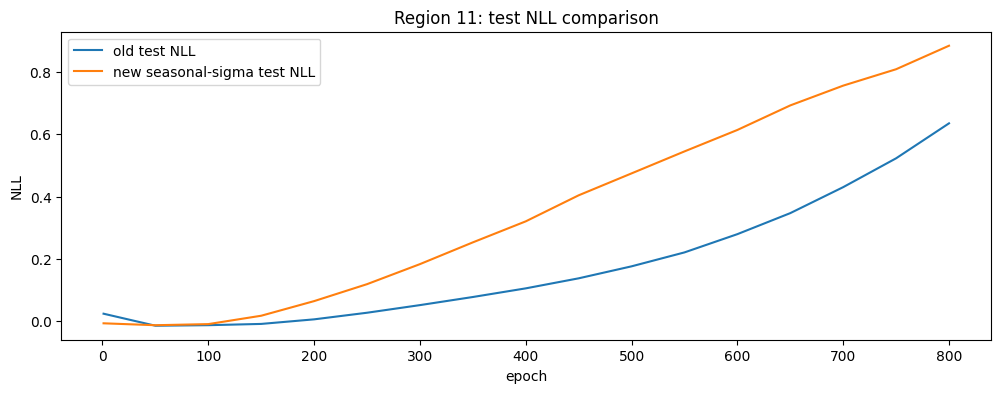

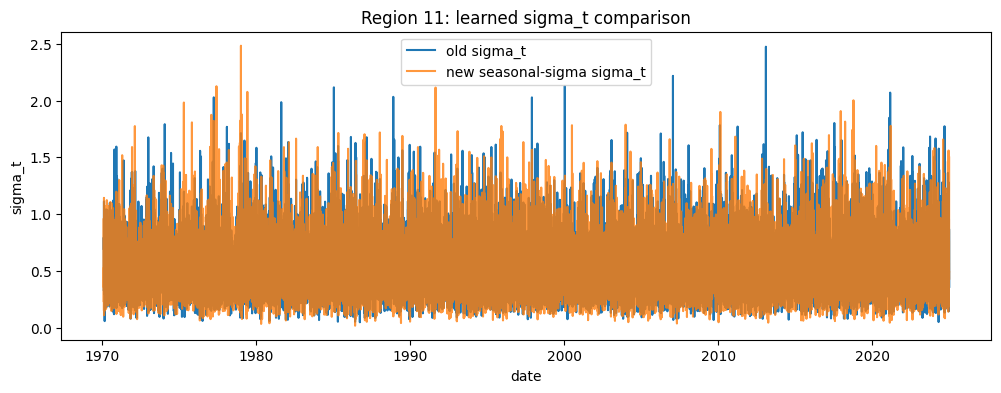

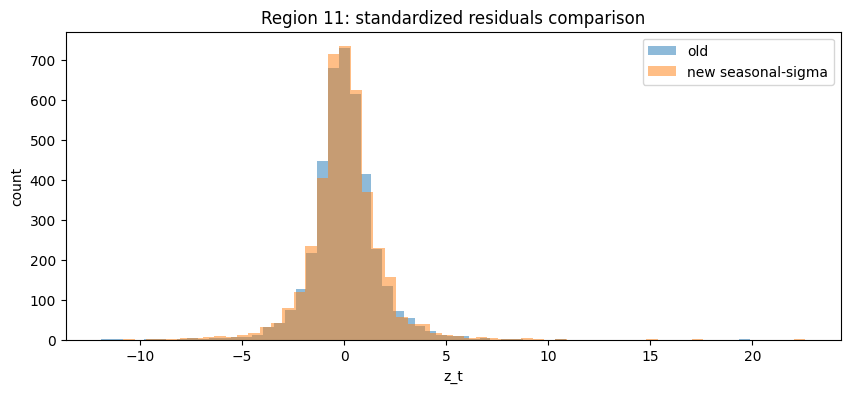

OLD z_mean, z_std: 0.036696166 1.6318564
NEW z_mean, z_std: 0.035262987 1.7955278


In [29]:
REGION_TO_COMPARE = comparison["region"].iloc[0]

art_old = region_artifacts[REGION_TO_COMPARE]
art_new = region_artifacts_seasonal_sigma[REGION_TO_COMPARE]

dates_old = art_old["df"].loc[art_old["idx_t"], "date"].values
dates_new = art_new["df"].loc[art_new["idx_t"], "date"].values

plt.figure(figsize=(12, 4))
plt.plot(art_old["epochs_logged"], art_old["test_curve"], label="old test NLL")
plt.plot(art_new["epochs_logged"], art_new["test_curve"], label="new seasonal-sigma test NLL")
plt.title(f"Region {REGION_TO_COMPARE}: test NLL comparison")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(dates_old, art_old["sigma_all"], label="old sigma_t")
plt.plot(dates_new, art_new["sigma_all"], label="new seasonal-sigma sigma_t", alpha=0.8)
plt.title(f"Region {REGION_TO_COMPARE}: learned sigma_t comparison")
plt.xlabel("date")
plt.ylabel("sigma_t")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(art_old["z_test"], bins=60, alpha=0.5, label="old")
plt.hist(art_new["z_test"], bins=60, alpha=0.5, label="new seasonal-sigma")
plt.title(f"Region {REGION_TO_COMPARE}: standardized residuals comparison")
plt.xlabel("z_t")
plt.ylabel("count")
plt.legend()
plt.show()

print("OLD z_mean, z_std:", np.mean(art_old["z_test"]), np.std(art_old["z_test"]))
print("NEW z_mean, z_std:", np.mean(art_new["z_test"]), np.std(art_new["z_test"]))

In [30]:
comparison[["region", "test_nll_old", "test_nll_new", "z_std_old", "z_std_new", "delta_test_nll", "delta_z_std"]] \
    .sort_values("delta_z_std")

,region,test_nll_old,test_nll_new,z_std_old,z_std_new,delta_test_nll,delta_z_std
2,27,0.906216,1.070315,1.762808,1.883002,0.164099,0.120195
0,11,0.635269,0.884825,1.631856,1.795528,0.249556,0.163671
5,44,0.360381,0.611480,1.470661,1.663702,0.251099,0.193041
4,32,0.697648,1.102702,1.692898,1.905433,0.405053,0.212535
7,53,0.428913,0.739711,1.498278,1.717993,0.310798,0.219715
6,52,0.328326,0.745381,1.388054,1.695826,0.417055,0.307771
1,24,0.603723,1.241148,1.622982,1.971742,0.637425,0.348759
3,28,0.505119,1.122558,1.533553,1.928124,0.617438,0.394572
